In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import matplotlib.cm as cm

In [3]:
#Run this to use Latex-like font
plt.rcParams.update({
    "mathtext.fontset": "cm", # 'cm' for Computer Modern, 'stix' for Times-like
    "font.family": "serif",
    "axes.formatter.use_mathtext": True,
    "font.size":14,
    'axes.prop_cycle':plt.cycler(color=plt.cm.Set1.colors)
})

# Debug

In [3]:
path = "./debug"
files = [f for f in Path(path).iterdir() if f.is_file()]
files

[WindowsPath('debug/high_temp.dat'),
 WindowsPath('debug/T = 0.9 long.dat'),
 WindowsPath('debug/T = 0.9.dat')]

### High temp prep

C:\Users\HP\AppData\Local\Temp\ipykernel_25000\700486126.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


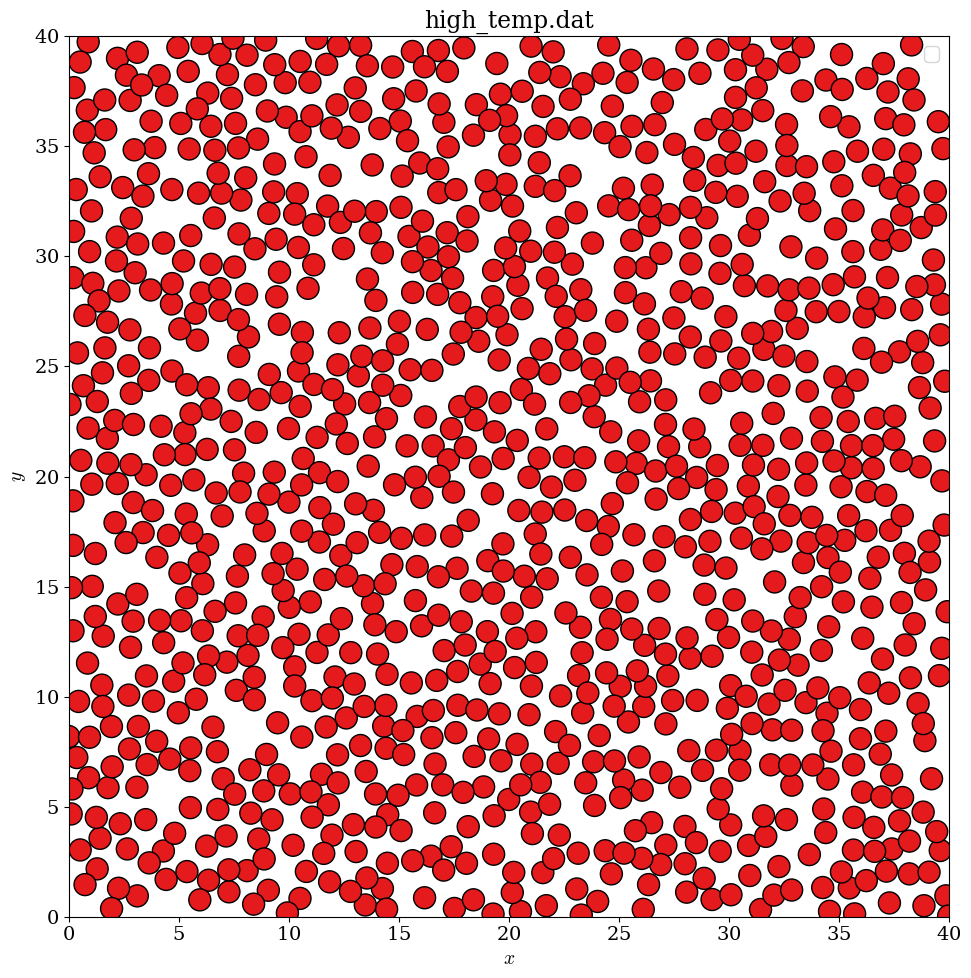

In [4]:
#data = np.loadtxt('./output/x_square.dat', comments = "#", unpack = True)

file = Path('debug/high_temp.dat')
filename = file.name
data = np.loadtxt(file, comments = "#", unpack = True)
X = data[1]
Y = data[2]
A = data[3]
L =40.
Np = 1024
patches = []



facecolors = [cm.Greens(x) for x in range(0,Np)]
for i in range(Np):
    circle = mpatches.Ellipse((X[i],Y[i]), A[i], A[i])  # 楕円の中心座標，長軸　短軸　（今回は真円）
    patches.append(circle)

p = PatchCollection(patches, alpha=1.0,ec='k')

fig, ax = plt.subplots(figsize=(10,10))
ax.add_collection(p)

ax.set_title(filename)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend()
ax.set_aspect('equal')
fig.tight_layout()
ax.set_xlim(0,L)
ax.set_ylim(0,L)

fig.savefig("./debug/image/"+filename+".png")

### T = 0.9 prep

C:\Users\HP\AppData\Local\Temp\ipykernel_25000\1284455483.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


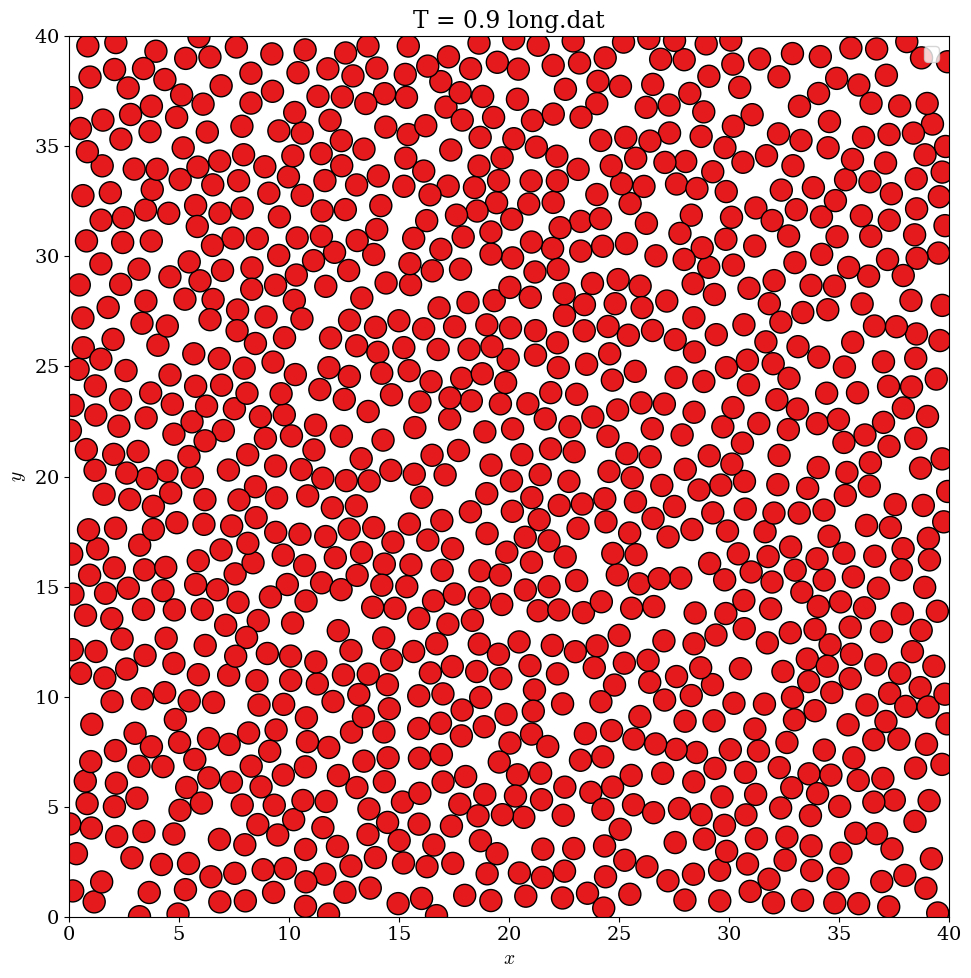

In [5]:
#data = np.loadtxt('./output/x_square.dat', comments = "#", unpack = True)
file = Path('debug/T = 0.9 long.dat')
filename = file.name
data = np.loadtxt(file, comments = "#", unpack = True)
X = data[1]
Y = data[2]
A = data[3]
L =40.
Np = 1024
patches = []



facecolors = [cm.Greens(x) for x in range(0,Np)]
for i in range(Np):
    circle = mpatches.Ellipse((X[i],Y[i]), A[i], A[i])  # 楕円の中心座標，長軸　短軸　（今回は真円）
    patches.append(circle)

p = PatchCollection(patches, alpha=1.0,ec='k')

fig, ax = plt.subplots(figsize=(10,10))
ax.add_collection(p)

ax.set_title(filename)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend()
ax.set_aspect('equal')
fig.tight_layout()
ax.set_xlim(0,L)
ax.set_ylim(0,L)

fig.savefig("./debug/image/"+filename+".png")

In [5]:
def MB_dist(x,T):
    return x*np.exp(-x**2/(2*T))/T



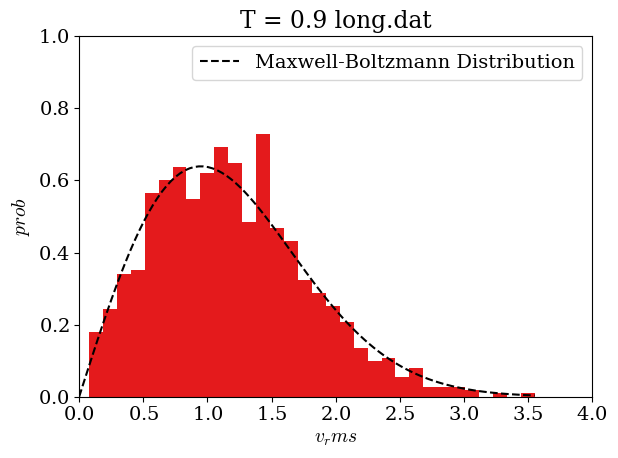

In [11]:
#data = np.loadtxt('./output/x_square.dat', comments = "#", unpack = True)
file = Path('debug/T = 0.9 long.dat')
filename = file.name
data = np.loadtxt(file, comments = "#", unpack = True)
X = data[1]
Y = data[2]
A = data[3]
VRms = data[4]
L =40.
Np = 1024
patches = []
Nbins = int(np.sqrt(Np))
vmax = VRms.max()
xTemp = np.linspace(0,vmax,100)
yTemp = MB_dist(xTemp, 0.9)

fig, ax = plt.subplots()

ax.hist(VRms,bins=Nbins,density=True)
ax.plot(xTemp, yTemp, color='k', ls='dashed',label = "Maxwell-Boltzmann Distribution")
ax.set_title(filename)
ax.set_xlabel(r'$v_rms$')
ax.set_ylabel(r'$prob$')
ax.set_ylim(0,1)
ax.set_xlim(0,4)
ax.legend()

fig.tight_layout()


fig.savefig("./debug/image/"+filename+"histogram"+".png")

# Maxwell Boltzmann Distribution

In [7]:
path = "./output/MBDist"
files = [f for f in Path(path).iterdir() if f.is_file()]
files
n = len(files)
n

11

In [9]:
import imageio.v3 as iio
import os
path = "./output/MBDist"
files = [f for f in Path(path).iterdir() if f.is_file()]
files
n = len(files)
print("number of file = " , n)
Temp = 0.9


animationFilesname=[]
for k in range(0,n):
    fig, ax = plt.subplots()
    #ax.set_title(r"$T^* = $" + filename)
   
    file = files[k]
    filename = file.name[-9:-4]
    data = np.loadtxt(file, comments = "#", unpack = True)
    
    
    Np = 1024
    Nbins = int(np.sqrt(Np))

    xTemp = np.linspace(0,data.max(),100)
    yTemp = MB_dist(xTemp, Temp)
    
    ax.hist(data,density=True,bins=Nbins)
    ax.set_title(rf"$T* = {Temp}$"+"\n"+r"$t = $" + filename)
    ax.set_xlabel(r'$v$')
    ax.set_ylabel(r'$Prob$')
    ax.set_xlim(0,4)
    ax.set_ylim(0,1)
    ax.plot(xTemp, yTemp, color='k', ls='dashed',label = "Maxwell-Boltzmann Distribution")
    ax.legend("top right")
    

    filename = f'./image/animation/frame_{k}.png'
    fig.savefig(filename)
    animationFilesname.append(filename)
    plt.close()




    

number of file =  11


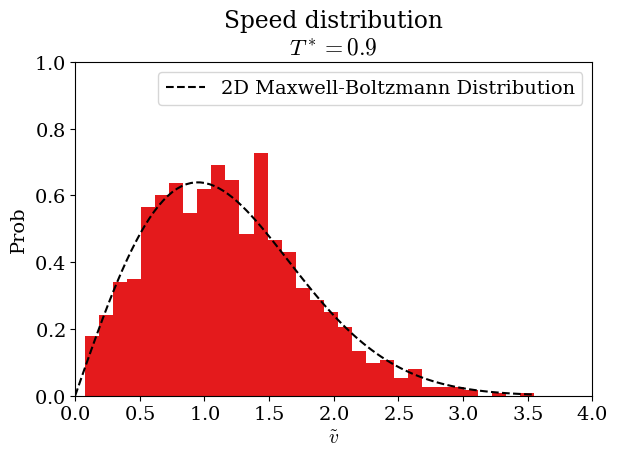

In [35]:
#data = np.loadtxt('./output/x_square.dat', comments = "#", unpack = True)
file = Path('./output/vDist_00.90.dat')
filename = file.name
VRms = np.loadtxt(file, comments = "#", unpack = True)

L =40.
Np = 1024
patches = []
Nbins = int(np.sqrt(Np))
vmax = VRms.max()
xTemp = np.linspace(0,vmax,100)
yTemp = MB_dist(xTemp, 0.9)

fig, ax = plt.subplots()

ax.hist(VRms,bins=Nbins,density=True)
ax.plot(xTemp, yTemp, color='k', ls='dashed',label = "2D Maxwell-Boltzmann Distribution")
ax.set_title("Speed distribution\n"+r"$T^*=0.9$")
ax.set_xlabel(r'$\tilde{v}$')
ax.set_ylabel("Prob")
ax.set_ylim(0,1)
ax.set_xlim(0,4)
ax.legend()

fig.tight_layout()


fig.savefig("./image/MBDist.png")

# Energy

In [4]:
path = "./output"
files = [f for f in Path(path).iterdir() if f.is_file()]
files

[WindowsPath('output/Energy.dat')]

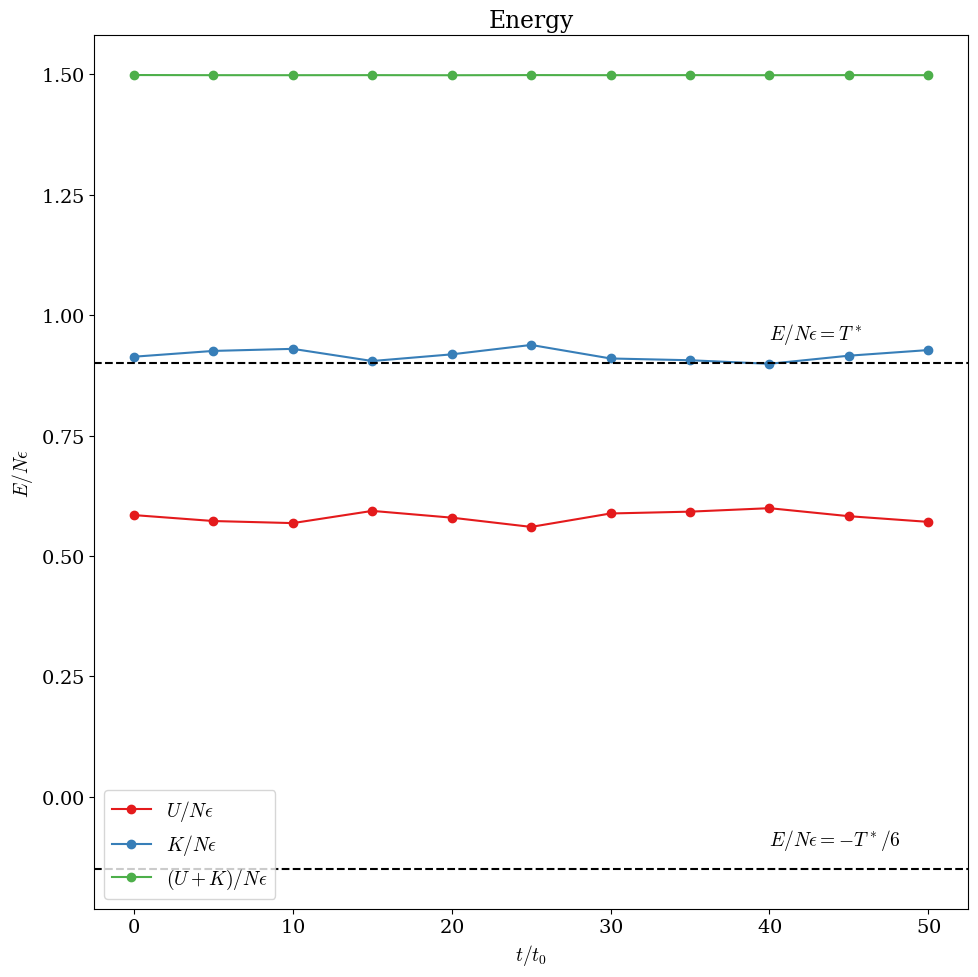

In [26]:
file = Path('./output/Energy.dat')
filename = file.name
data = np.loadtxt(file, comments = "#", unpack = True)
T = data[0]
U = data[1]
K = data[2]
E = data[3]
L =40.
Np = 1024
Temp = 0.9
dim = 2

fig, ax = plt.subplots(figsize=(10,10))


ax.plot(T,U/Np,label=r"$U/N\epsilon$",marker='o')
ax.plot(T,K/Np,label=r"$K/N\epsilon$",marker='o')
ax.plot(T,E/Np,label=r"$(U+K)/N\epsilon$",marker='o')

ax.axhline(Temp, ls = "dashed", color="black")
ax.axhline(-2*Temp/12, ls = "dashed", color="black")

ax.set_title("Energy")
ax.set_xlabel(r'$t/t_0$')
ax.set_ylabel(r'$E/N\epsilon$')
ax.text(40,0.95,r"$E/N\epsilon=T^*$")
ax.text(40,-0.1,r"$E/N\epsilon=-T^*/6$")
ax.legend()

fig.tight_layout()


fig.savefig("./image/Energy.png")